# Group No: [1]
## Members:
- Wadha Abdulla - U25100392
- Samar Salem - U25100513
- Ghayah Mohamed - U25104167
- Meera Khamis - U25100567
- Nouf Ali - U25101228

**In-Class Team-Based Learning Activity** : Exploring Global Health & Wealth with Gapminder Data **[15 MARKS]**

---

## Objective

In this activity you will work in teams to explore **global health and economic data**.

You will work with **two separate Gapminder CSV datasets** that share a common key (`country`) and must be **joined (merged by column)** to answer meaningful questions about the relationship between wealth, health, and population.

### Datasets

Download the datasets from the Blackboard:

| File | Description |
|------|-------------|
| `Gapminder_Health.csv` | Country, Year, Continent, Life expectancy, Population |
| `gapminder_economy.csv` | Country, Year, GDP per capita |

> **Note :** Both datasets contain one row per (country, year) pair. They share `country` and `year` columns but carry **different** variables — you must **join them on `country`** to get a combined view.

### Key Columns After Joining

| Column | Dataset | Description |
|--------|---------|-------------|
| `country` | both (join key) | Country name |
| `continent` | health | Geographic region |
| `year` | both | 5-year interval (1952–2007) |
| `lifeExp` | health | Life expectancy at birth (years) |
| `pop` | health | Population |
| `gdpPercap` | economy | GDP per capita (USD, inflation-adjusted) |

### You will:
1. Load and **join (merge by columns)** the two datasets on `country`
2. **Explore** the joined data using Table methods
3. **Visualise** patterns with Table-based plots
4. **Define and use functions** with `.apply()`



<a href="https://colab.research.google.com/github/Wadha-Abdulla/Group_1_Gapminder_Analysis/blob/main/Group_1_Gapminder_Analysis.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Setup – Install & Import

In [ ]:
!pip install datascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.0 MB/s eta 0:00:00


In [ ]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
print('Libraries loaded successfully!')

Libraries loaded successfully!


---

## Task 1 — Load and Join the Datasets **[2 marks]**

**Goal :** Load each CSV file into its own `Table`, then use `.join()` to merge them by the shared key `country`.

The `datascience` library's `.join()` works like a database inner join:

```python
merged = table_A.join('shared_column', table_B)
```

### Step 1.1 – Download and load the health dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gapminder_Health.csv to Gapminder_Health.csv


In [ ]:
# Load the Gapminder Health dataset and assign it to 'health' table variable
health = Table.read_table("Gapminder_Health.csv")

# Show the first 5 records
health.show(5)

# Show the number of columns and number of rows
print("Number of rows:", health.num_rows)
print("Number of columns:", health.num_columns)

country,year,continent,lifeExp,pop
Afghanistan,1952,Asia,28.801,8.42533e+06
Afghanistan,1957,Asia,30.332,9.24093e+06
Afghanistan,1962,Asia,31.997,1.02671e+07
Afghanistan,1967,Asia,34.02,1.1538e+07
Afghanistan,1972,Asia,36.088,1.30795e+07


Number of rows: 1704
Number of columns: 5


### Step 1.2 – Load the economy dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gapminder_Economy.csv to Gapminder_Economy.csv


In [ ]:
# Load the Gapminder Economy dataset and assign it to 'economy' table variable
economy = Table.read_table("Gapminder_Economy.csv")

# Show the first 5 records
economy.show(5)

# Show the number of columns and number of rows
print("Number of rows:", economy.num_rows)
print("Number of columns:", economy.num_columns)

country,year,gdpPercap
Afghanistan,1952,779.445
Afghanistan,1957,820.853
Afghanistan,1962,853.101
Afghanistan,1967,836.197
Afghanistan,1972,739.981


Number of rows: 1632
Number of columns: 3


### Step 1.3 – Filter both tables to the **same year** before joining

Because each country appears multiple times (once per year), first filter to a single year so each country appears exactly once — making the join unambiguous.

> Use **year 2007** (the most recent in the dataset).


In [ ]:
# Keep only 2007 records in two datasets and assign them to new Tables
# Display how many countries there are in two new tables: health_2007 and economy_2007

# Filter health dataset
health_2007 = health.where('year', 2007)

# Show first rows
print("First rows of year 2007 health dataset:")
health_2007.show(5)


# Filter economy dataset
economy_2007 = economy.where('year', 2007)

# Show first rows
print("-"*50)
print("\nFirst rows of year 2007 economy dataset:")
economy_2007.show(5)


# Check number of countries
print("-"*50)
print("\nHealth 2007 countries:", health_2007.num_rows)
print("Economy 2007 countries:", economy_2007.num_rows)

First rows of year 2007 health dataset:


country,year,continent,lifeExp,pop
Afghanistan,2007,Asia,43.828,3.18899e+07
Albania,2007,Europe,76.423,3.60052e+06
Algeria,2007,Africa,72.301,3.33332e+07
Angola,2007,Africa,42.731,1.24205e+07
Argentina,2007,Americas,75.32,4.03019e+07


--------------------------------------------------

First rows of year 2007 economy dataset:


country,year,gdpPercap
Afghanistan,2007,974.58
Albania,2007,5937.03
Algeria,2007,6223.37
Angola,2007,4797.23
Argentina,2007,12779.4


--------------------------------------------------

Health 2007 countries: 142
Economy 2007 countries: 136


### Step 1.4 – Join the two tables on `country`

In [ ]:
# Join health data with economy data on 'country'
# health_2007 has: country, continent, year, lifeExp, pop
# economy_2007 has: country, year, gdpPercap

# Join the two tables on 'country'
joined = health_2007.join('country', economy_2007)

# Show result
print("Joined dataset:")
joined.show(5)

# Remove the duplicate column (year_2)
joined = joined.drop('year_2')

# Show cleaned result
print("-"*68)
print("\nAfter filtering into a single year:")
joined.show(5)

'''
The column year_2 is created during the join because both tables contain a year column.
Since both datasets were filtered to the same year (2007),
year_2 is redundant and can be removed to clean the data.
'''

Joined dataset:


country,year,continent,lifeExp,pop,year_2,gdpPercap
Afghanistan,2007,Asia,43.828,3.18899e+07,2007,974.58
Albania,2007,Europe,76.423,3.60052e+06,2007,5937.03
Algeria,2007,Africa,72.301,3.33332e+07,2007,6223.37
Angola,2007,Africa,42.731,1.24205e+07,2007,4797.23
Argentina,2007,Americas,75.32,4.03019e+07,2007,12779.4


--------------------------------------------------------------------

After filtering into a single year:


country,year,continent,lifeExp,pop,gdpPercap
Afghanistan,2007,Asia,43.828,3.18899e+07,974.58
Albania,2007,Europe,76.423,3.60052e+06,5937.03
Algeria,2007,Africa,72.301,3.33332e+07,6223.37
Angola,2007,Africa,42.731,1.24205e+07,4797.23
Argentina,2007,Americas,75.32,4.03019e+07,12779.4


'\nThe column year_2 is created during the join because both tables contain a year column.\nSince both datasets were filtered to the same year (2007),\nyear_2 is redundant and can be removed to clean the data.\n'

**✏️ Question 1.1 :** How many columns does the joined table have? Explain the columns in the joined table.









The joined table has 6 columns.

Explanation of the columns:
1. country: The country name (used as the join key)
2. year: The year of the data (2007)
3. continent: The geographic region of the country
4. lifeExp: Life expectancy at birth (in years)
5. pop: Population of the country
6. gdpPercap: GDP per capita (economic indicator)

Note:
The column 'year_2' was removed because it contained the same values as 'year' (both are 2007), making it redundant.

**✏️ Question 1.2 :** What would happen if we joined without filtering to a single year first? Why?

If we joined the datasets without filtering to a single year first, the resulting table would contain duplicate and incorrect rows.

This happens because each country appears multiple times once for each year in both datasets. When performing the join, every row for a country in the health dataset would match with every row for the same country in the economy dataset.

As a result, the join would create many combinations (Cartesian-like effect), leading to inflated data and inaccurate analysis.

Therefore, filtering to a single year ensures that each country appears only once, making the join correct and unambiguous.

---

## Task 2 — Explore the Joined Data Using Tables **[3 marks]**

**Goal :** Use `.select()`, `.where()`, `.group()`, and `.sort()` to extract insights.

### Step 2.1 – Select relevant columns


In [ ]:
# Keep the columns in world we care about and give them clean names
# They are 'country', 'continent', 'lifeExp', 'pop', 'gdpPercap'
world = joined.select('country', 'continent', 'lifeExp', 'pop', 'gdpPercap')

# show the first 5 records
world.show(5)

country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Albania,Europe,76.423,3.60052e+06,5937.03
Algeria,Africa,72.301,3.33332e+07,6223.37
Angola,Africa,42.731,1.24205e+07,4797.23
Argentina,Americas,75.32,4.03019e+07,12779.4


### Step 2.2 – Filter rows

In [ ]:
# Create a new table, high_life, containing the countries with life expectancy above 80 years
high_life = world.where('lifeExp', are.above(80))

# Display them
high_life.show()

country,continent,lifeExp,pop,gdpPercap
Australia,Oceania,81.235,2.04342e+07,34435.4
Canada,Americas,80.653,3.33901e+07,36319.2
France,Europe,80.657,6.10839e+07,30470
Iceland,Europe,81.757,301931,36180.8
Israel,Asia,80.745,6.42668e+06,25523.3
Italy,Europe,80.546,5.81477e+07,28569.7
Japan,Asia,82.603,1.27468e+08,31656.1
New Zealand,Oceania,80.204,4.11577e+06,25185
Norway,Europe,80.196,4.62793e+06,49357.2
Spain,Europe,80.941,4.04482e+07,28821.1


In [ ]:
# Create a new table, asia, containing the countries in Asia only
asia = world.where('continent', 'Asia')

# Display how many countries in Asia
print("Number of countries in Asia:", asia.num_rows)

# Sort the countries in alphabetic order and show the first 10 of them
asia.sort('country').show(10)

Number of countries in Asia: 29


country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Bahrain,Asia,75.635,708573,29796
Bangladesh,Asia,64.062,1.50448e+08,1391.25
Cambodia,Asia,59.723,1.41319e+07,1713.78
China,Asia,72.961,1.31868e+09,4959.11
India,Asia,64.698,1.1104e+09,2452.21
Indonesia,Asia,70.65,2.23547e+08,3540.65
Iran,Asia,70.964,6.94536e+07,11605.7
Iraq,Asia,59.545,2.74996e+07,4471.06
Israel,Asia,80.745,6.42668e+06,25523.3


### Step 2.3 – Summarise data

In [ ]:
# Calculate the Average life expectancy per continent
avg_life_by_continent = world.select('continent', 'lifeExp').group('continent', np.average)

# and show them in descending order.
avg_life_by_continent.sort('lifeExp average', descending=True)

continent,lifeExp average
Oceania,80.7195
Europe,77.6486
Americas,73.6081
Asia,70.4557
Africa,54.9626


In [ ]:
# Calculate the Average GDP per capita per continent
avg_gdpPercap_by_continent = world.select('continent', 'gdpPercap').group('continent', np.average)

# and display them in ascending order
avg_gdpPercap_by_continent.sort('gdpPercap average')

continent,gdpPercap average
Africa,3134.39
Americas,11003
Asia,11884.9
Europe,25054.5
Oceania,29810.2


**✏️ Question 2.1 :** Which continent has the highest average life expectancy in 2007? Which has the lowest?




Ocenia has the highest average life expectancy in 2007.

*   Average for Oceania = 80.7195

While Africa has the lowest average life expectancy.

*   Average for Africa = 54.9626

**✏️ Question 2.2 :** Write code to find the **top 5 countries by GDP per capita** in the dataset. Are any of them surprising?



In [ ]:
# Your code for Question 2.2 here

top5_gdp = world.sort('gdpPercap', descending=True).select('country', 'continent', 'gdpPercap')
top5_gdp.show(5)


country,continent,gdpPercap
Norway,Europe,49357.2
Kuwait,Asia,47307
Singapore,Asia,47143.2
United States,Americas,42951.7
Ireland,Europe,40676


Yes. While Norway and the United States are expected due to their strong economies, Kuwait and Ireland may be surprising. Kuwait’s rank is influenced by oil wealth and a small population, while Ireland’s high GDP per capita is boosted by multinational corporations and its relatively small population size.

---

## Task 3 — Visualise the Data Using Table-Based Plots **[5 marks]**

**Goal :** Use `.barh()`, `.hist()`, and `.scatter()` to reveal patterns.

### Step 3.1 – Bar chart: average life expectancy by continent


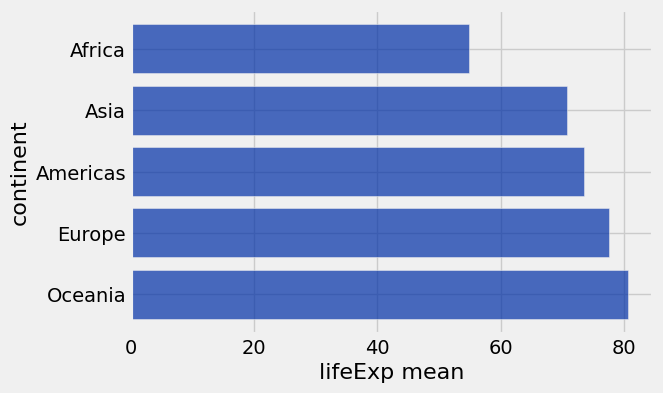

In [ ]:
# Show the Average Life Expectancy by Continent (2007) using barh graphic

# Filter for 2007
data_2007 = health.where("year", 2007)

# Group by continent and calculate mean life expectancy
avg_life = data_2007.group("continent", np.mean)

# Keep only needed columns
avg_life = avg_life.select("continent", "lifeExp mean")

# Sort for better display
avg_life = avg_life.sort("lifeExp mean")

# Plot horizontal bar chart
avg_life.barh("continent", "lifeExp mean")



### Step 3.2 – Histogram: distribution of GDP per capita

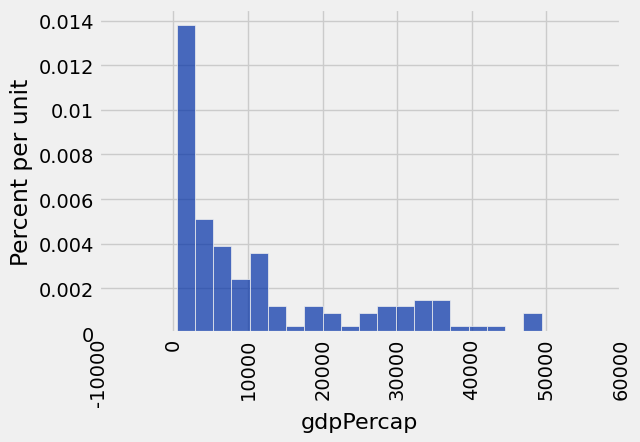

In [ ]:
# Show the Distribution of GDP per Capita Across Countries (2007) using a histogram with 20 bins

# Filter for 2007
eco_2007 = economy.where("year", 2007)

# Plot histogram with 20 bins
eco_2007.hist("gdpPercap", bins=20)

### Step 3.3 – Scatter plot: GDP per capita vs. life expectancy

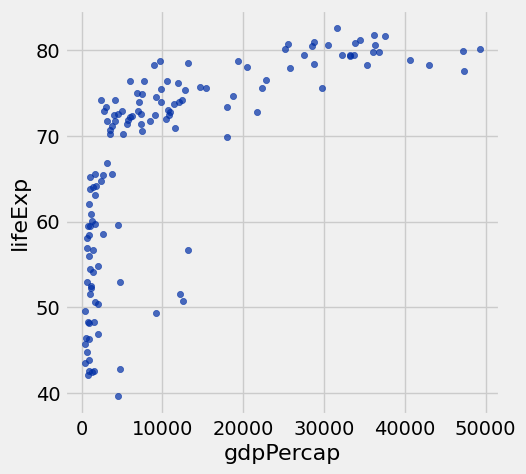

In [22]:
# Show GDP per Capita vs. Life Expectancy (2007) using a Scatter plot.
# Filter both datasets
health_2007 = health.where("year", 2007)
economy_2007 = economy.where("year", 2007)

# Join after filtering
merged_2007 = health_2007.join("country", economy_2007)

# Remove duplicate column
merged_2007 = merged_2007.drop("year_2")

# Scatter plot
merged_2007.scatter("gdpPercap", "lifeExp")

**✏️ Question 3.1 :** Describe the relationship between GDP per capita and life expectancy. Is it linear or non-linear? What does this suggest?






There is a positive relationship between GDP per capita and life expectancy. As GDP per capita increases, life expectancy also increases. relationship is non-linear. This suggests that after a certain point, more wealth has less effect on improving life expectancy.




**✏️ Question 3.2 (Challenge) :** Create a bar chart showing the **5 countries with the lowest life expectancy**. What continent are most of them on?


country,continent,lifeExp
Swaziland,Africa,39.613
Mozambique,Africa,42.082
Zambia,Africa,42.384
Sierra Leone,Africa,42.568
Lesotho,Africa,42.592


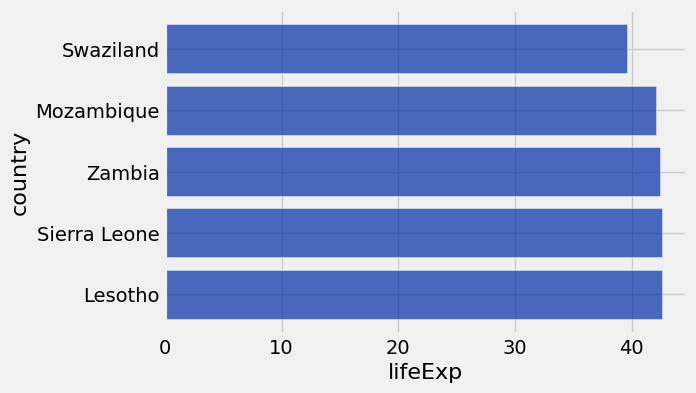

In [23]:
# Your code for Question 3.2 here

# Filter for 2007
data_2007 = health.where("year", 2007)

# Sort by life expectancy (lowest first)
lowest_life = data_2007.sort("lifeExp")

# Get bottom 5 countries
bottom_5 = lowest_life.take(np.arange(5))

# Select relevant columns
bottom_5 = bottom_5.select("country", "continent", "lifeExp")

# Plot bar chart
bottom_5.barh("country", "lifeExp")

# Show table (useful to answer question)
bottom_5


Most of the countries with the lowest life expectancy are from Africa, showing that this region faces more health and development challenges compared to others.

---

## Task 4 — Define and Use Functions with Tables **[5 marks]**

**Goal :** Write Python functions and apply them to table columns.

### Step 4.1 – Classify countries by income level

The World Bank uses GDP per capita thresholds to classify countries. The following defines a simplified version
and will be used to develop the function:

| Category | GDP per capita (USD) |  String to be returned |
|----------|----------------------|------------------------|
| Low income | < 1 000 |          'Low income'           |
| Lower-middle income | 1 000 – 3 999 | 'Lower-middle income'   |
| Upper-middle income | 4 000 – 12 999 | 'Upper-middle income' |
| High income | ≥ 13 000 | 'High income' |


In [24]:
# Implement income_group function
# It returns a World-Bank-style income classification based on GDP per capita.

#Your code here
def income_group(gdp):
    if gdp < 1000:
        return 'Low income'
    elif 1000 <= gdp <= 3999:
        return 'Lower-middle income'
    elif 4000 <= gdp <= 12999:
        return 'Upper-middle income'
    else:
        return 'High income'



# Quick test for your function
print(income_group(500))    # Low income
print(income_group(2500))   # Lower-middle income
print(income_group(8000))   # Upper-middle income
print(income_group(40000))  # High income


Low income
Lower-middle income
Upper-middle income
High income


In [25]:
# Apply the function to the gdpPercap column
world = world.with_column('income_group', world.apply(income_group, 'gdpPercap'))

# Display the first 5 records
world.show(5)



country,continent,lifeExp,pop,gdpPercap,income_group
Afghanistan,Asia,43.828,3.18899e+07,974.58,Low income
Albania,Europe,76.423,3.60052e+06,5937.03,Upper-middle income
Algeria,Africa,72.301,3.33332e+07,6223.37,Upper-middle income
Angola,Africa,42.731,1.24205e+07,4797.23,Upper-middle income
Argentina,Americas,75.32,4.03019e+07,12779.4,Upper-middle income


In [26]:
# How many countries in each income group?
income_counts = world.group('income_group')

income_counts
# Use an appropriate function to answer this question




income_group,count
High income,39
Low income,19
Lower-middle income,35
Upper-middle income,43


The .group('income_group') function groups countries based on their assigned income category and counts how many fall into each group.

This provides a summary showing the distribution of countries across:

- Low income
- Lower-middle income
- Upper-middle income
- High income



---

## Grading Distribution (Out of 25)

| Task | Description | Marks |
|------|-------------|-------|
| 1 | Load and join datasets with `.join()` | 2 |
| 2 | Explore with `.select()`, `.where()`, `.group()` | 3 |
| 3 | Visualise with `.barh()`, `.hist()`, `.scatter()` | 5 |
| 4 | Functions & `.apply()` | 5 |
| **Total** | | **15** |


## Submission Instructions

- **1. File Requirements**
  - **File Name :** Save your notebook as `Group_No_Gapminder_Analysis.ipynb`. Replace `Group_No` with your assigned group number.
  - **Self-Contained :** Run all cells before submitting. Include all outputs and Markdown explanations.
  - **Colab Compatibility :** Test that the notebook opens and runs via "Open in Colab":

    [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your_username/your_repo/blob/main/Group_No_Gapminder_Analysis.ipynb)

    Replace `your_username`, `your_repo`, and `Group_No` with your actual Github username, repository name, and group no, accordingly.

- **2. Group Information**
  Include the group number and all member names at the bottom of this text block.

- **3. Submission Process**
  - **GitHub :** Upload the completed notebook to a public repository with a `README.md`.
  - **Blackboard :** Submit the GitHub link **and** upload the `.ipynb` file as backup.


# Group No: [Your Group No]
## Members:
- Member 1 Name
- Member 2 Name
- Member 3 Name
- ...